In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [9]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [10]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


Processing: RevenueCenter_5
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0842 - val_loss: 0.0719
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0126 - val_loss: 0.0172
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0102 - val_loss: 0.0141
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0102 - val_loss: 0.0149
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0102 - val_loss: 0.0172
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0081 - val_loss: 0.0198
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0104 - val_loss: 0.0150
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0076 - val_loss: 0.0154
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0092 - val_loss: 0.0156
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0092 - val_loss: 0.0173
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0093 - val_loss: 0.0201
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

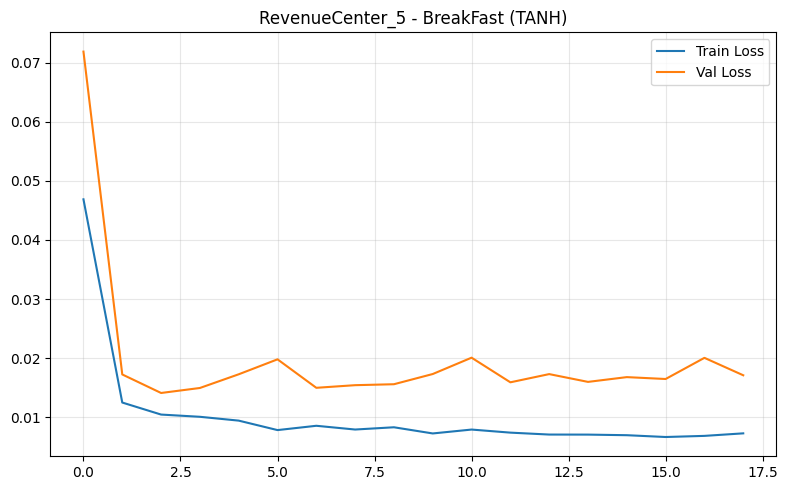

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


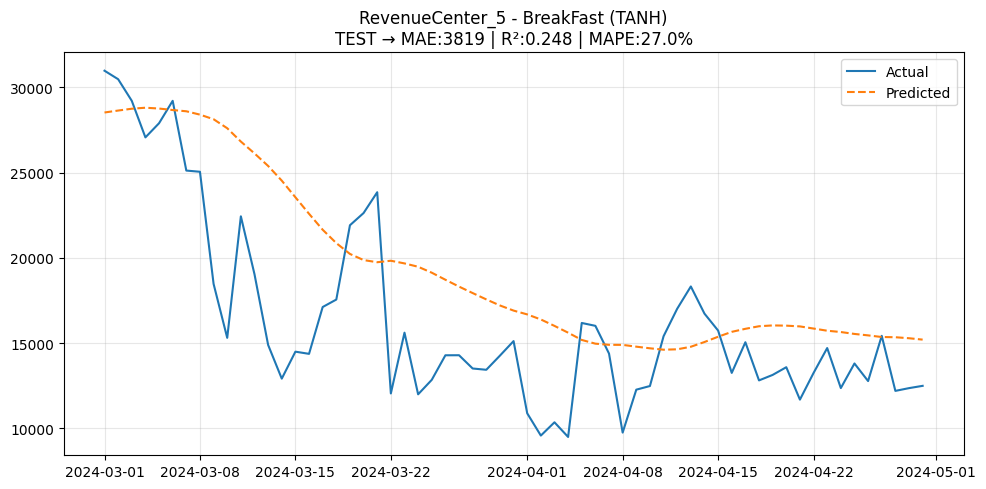

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0149 - val_loss: 0.0166
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0139 - val_loss: 0.0164
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0193 - val_loss: 0.0170
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0130 - val_loss: 0.0163
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0135 - val_loss: 0.0160
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0156 - val_loss: 0.0178
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0143 - val_loss: 0.0160
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0115 - val_loss: 0.0162
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0160 - val_loss: 0.0163
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0120 - val_loss: 0.0166
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0087 - val_loss: 0.0169
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

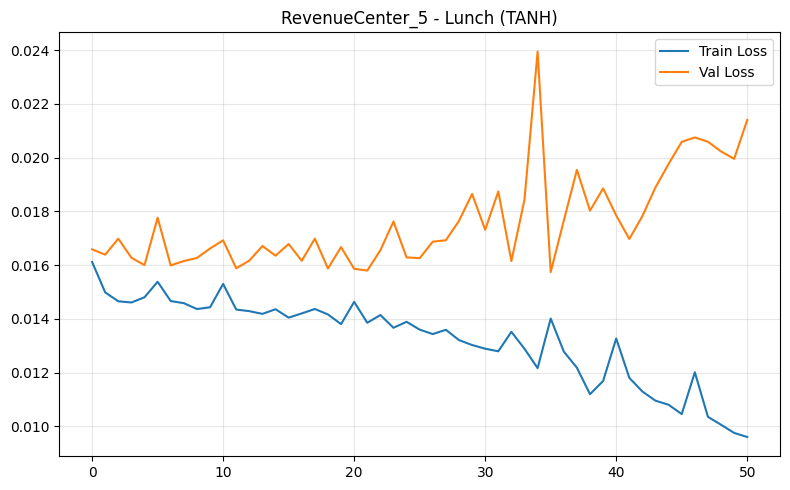

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


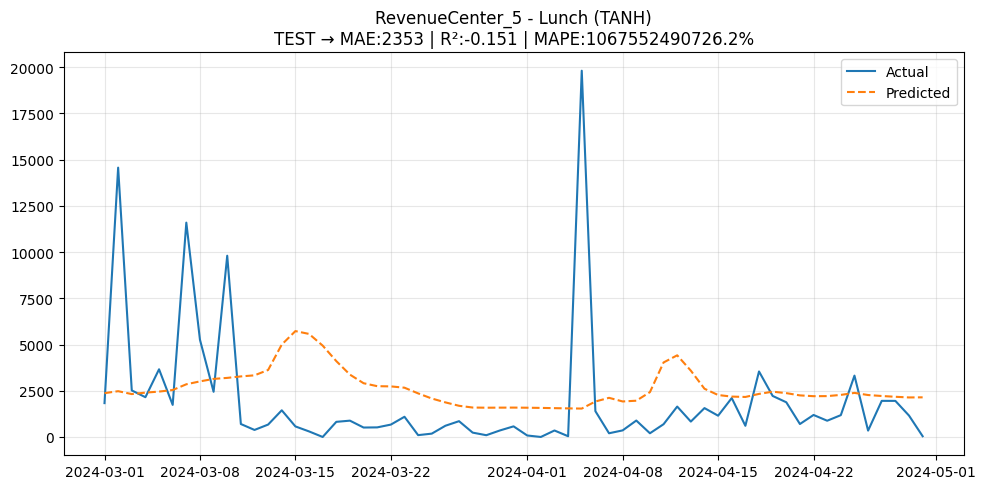

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0327 - val_loss: 0.0567
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0223 - val_loss: 0.0542
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0196 - val_loss: 0.0548
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0184 - val_loss: 0.0554
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0185 - val_loss: 0.0561
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0190 - val_loss: 0.0559
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0167 - val_loss: 0.0588
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0197 - val_loss: 0.0564
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0215 - val_loss: 0.0605
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0174 - val_loss: 0.0586
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0207 - val_loss: 0.0619
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0

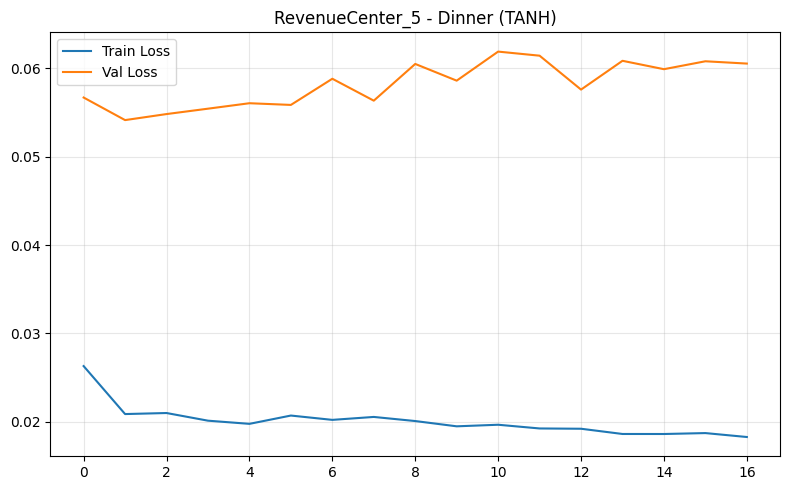

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


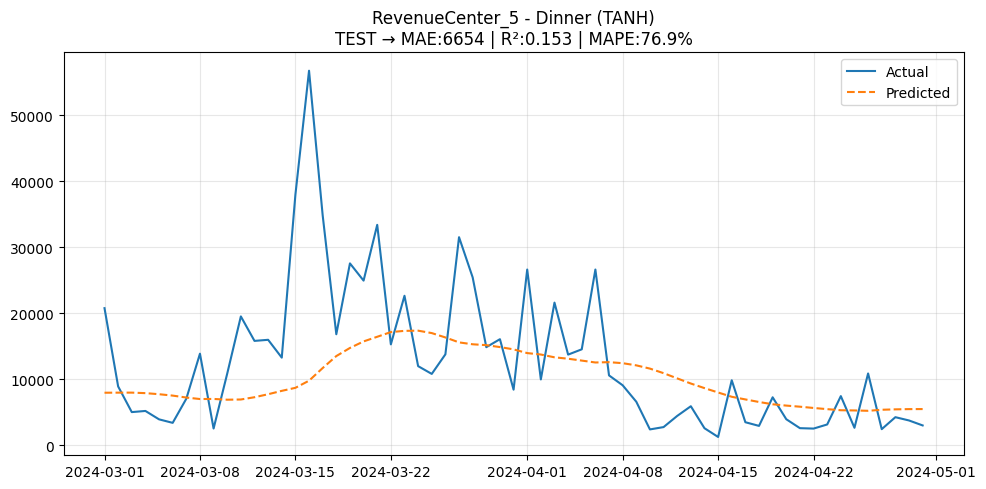

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_7
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0123 - val_loss: 0.0048
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0086 - val_loss: 0.0048
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0084 - val_loss: 0.0046
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0091 - val_loss: 0.0046
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0098 - val_loss: 0.0046
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0110 - val_loss: 0.0046
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0123 - val_loss: 0.0046
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0080 - val_loss: 0.0046
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0093 - val_loss: 0.0044
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0106 - val_loss: 0.0044
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0093 - val_loss: 0.0044
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

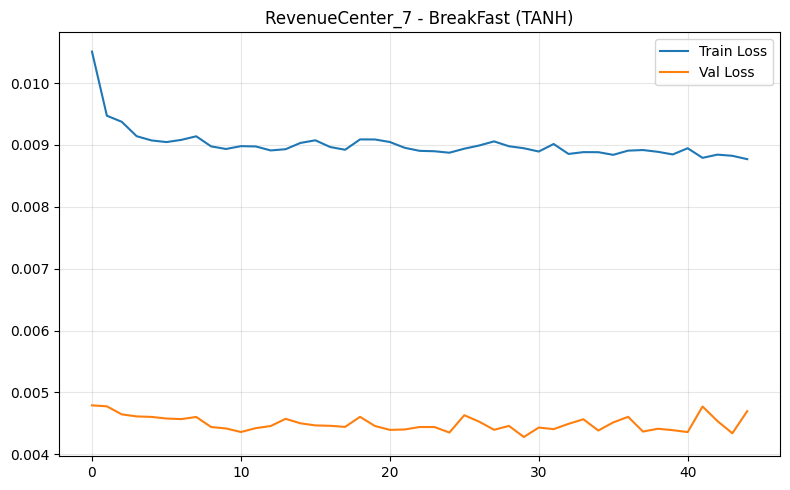

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


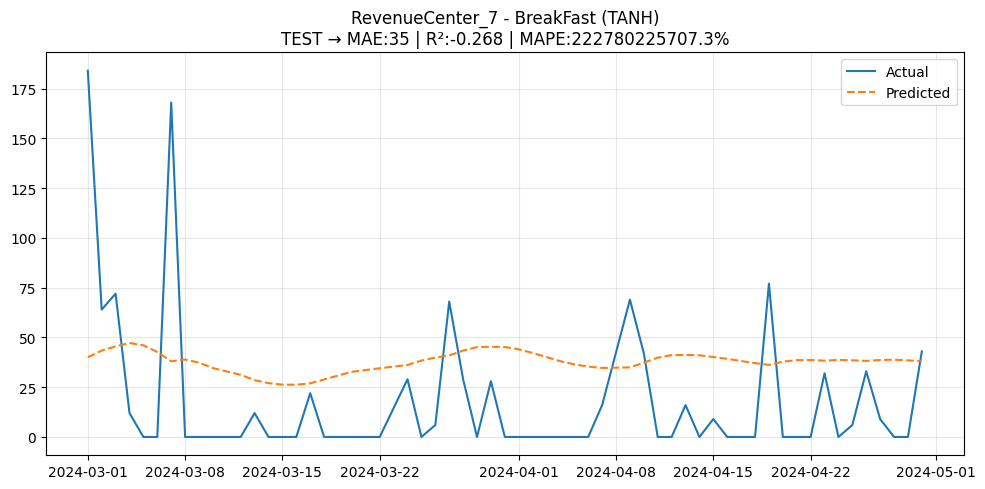

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0116 - val_loss: 0.0418
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0127 - val_loss: 0.0404
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0119 - val_loss: 0.0414
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0135 - val_loss: 0.0408
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0149 - val_loss: 0.0410
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0130 - val_loss: 0.0408
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0112 - val_loss: 0.0405
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0119 - val_loss: 0.0408
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0097 - val_loss: 0.0402
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0084 - val_loss: 0.0401
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0108 - val_loss: 0.0408
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

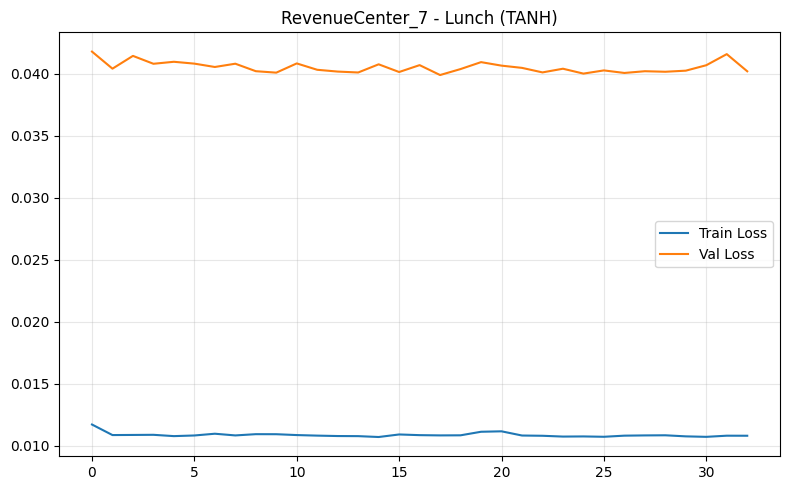

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


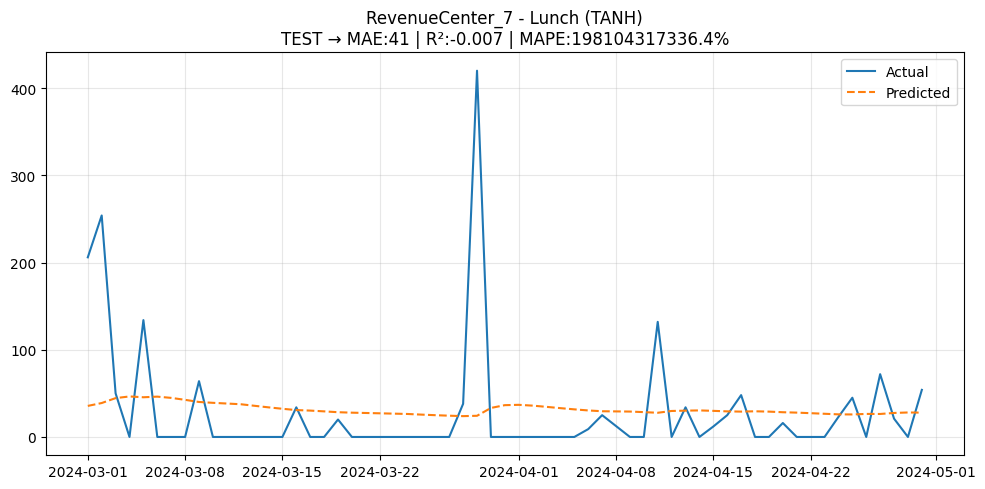

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0227 - val_loss: 0.0899
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0189 - val_loss: 0.0803
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0171 - val_loss: 0.0822
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0200 - val_loss: 0.0808
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0168 - val_loss: 0.0795
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0164 - val_loss: 0.0795
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0185 - val_loss: 0.0833
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0186 - val_loss: 0.0776
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0195 - val_loss: 0.0854
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0164 - val_loss: 0.0758
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0184 - val_loss: 0.0838
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0

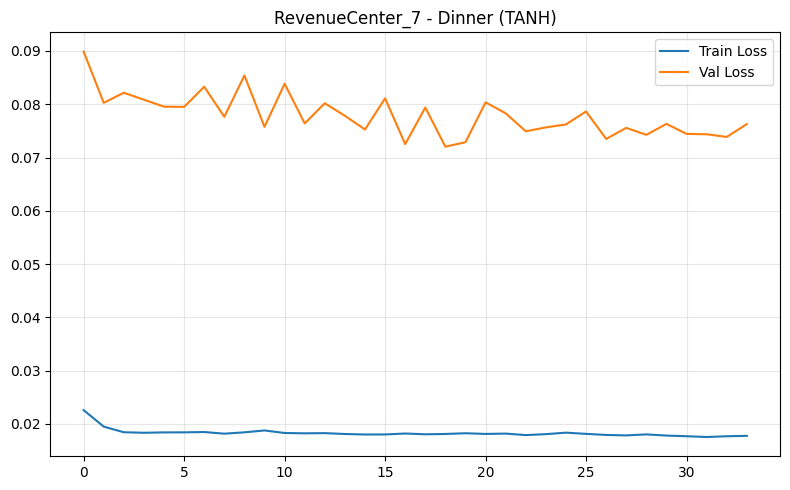

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


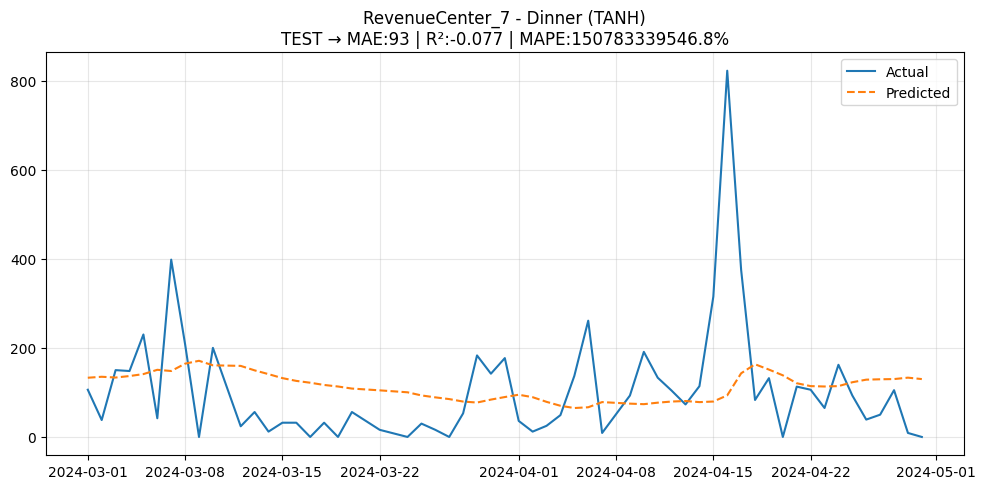

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_2
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0173 - val_loss: 0.0307
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0149 - val_loss: 0.0215
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0172 - val_loss: 0.0277
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0122 - val_loss: 0.0226
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0160 - val_loss: 0.0219
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0219 - val_loss: 0.0310
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0165 - val_loss: 0.0254
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0121 - val_loss: 0.0250
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0153 - val_loss: 0.0257
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0168 - val_loss: 0.0259
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0155 - val_loss: 0.0235
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

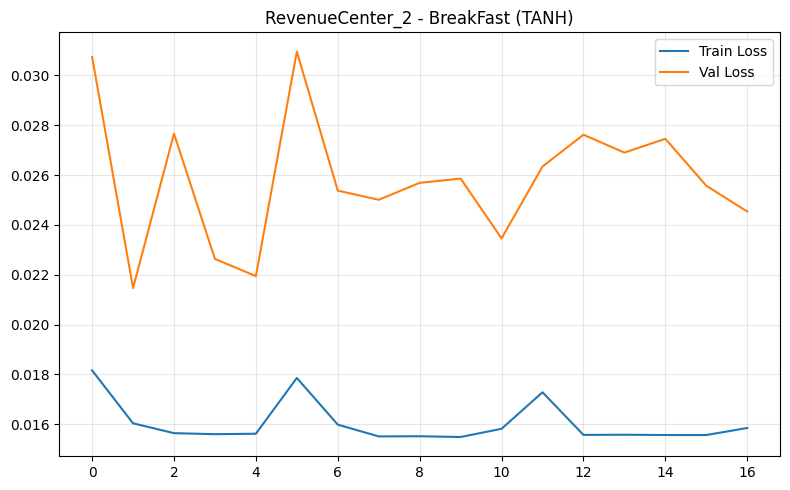

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


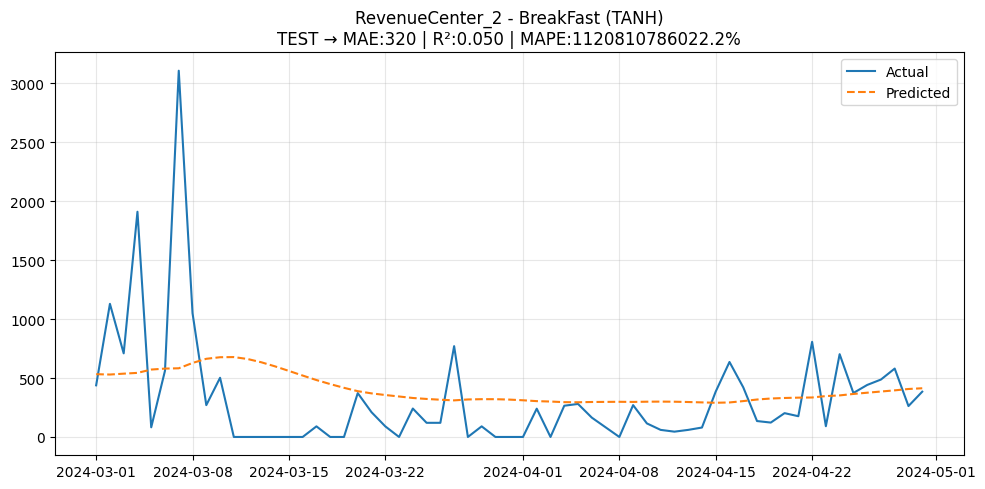

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0271 - val_loss: 0.0644
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0165 - val_loss: 0.0567
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0131 - val_loss: 0.0567
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0153 - val_loss: 0.0557
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0204 - val_loss: 0.0653
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0141 - val_loss: 0.0550
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0154 - val_loss: 0.0687
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0175 - val_loss: 0.0565
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0152 - val_loss: 0.0643
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0192 - val_loss: 0.0590
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0150 - val_loss: 0.0613
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0

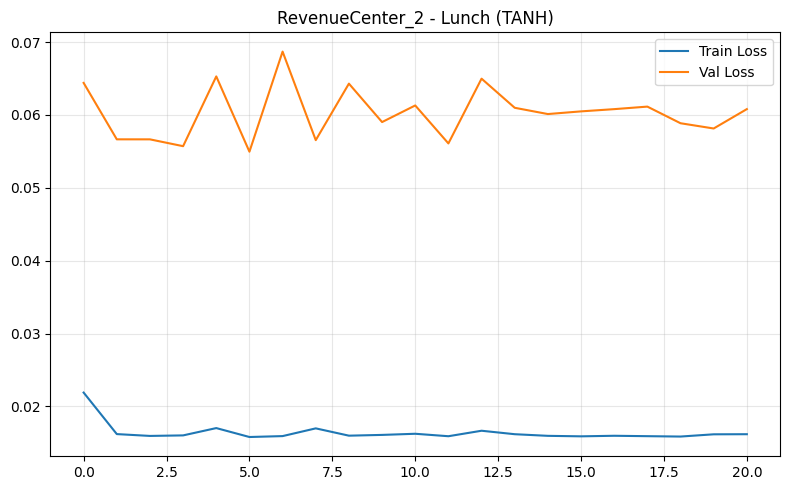

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


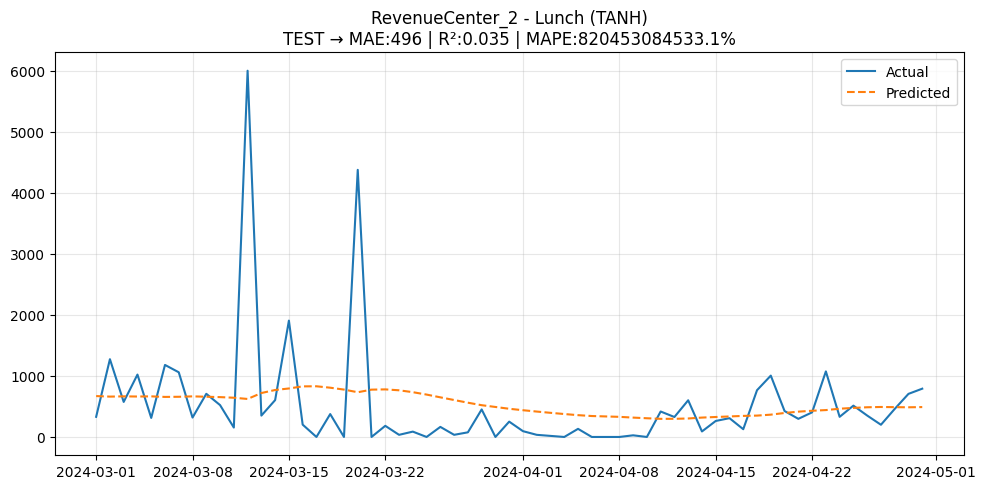

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0024 - val_loss: 0.0258
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021 - val_loss: 0.0268
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0016 - val_loss: 0.0258
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017 - val_loss: 0.0270
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0023 - val_loss: 0.0277
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016 - val_loss: 0.0254
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0022 - val_loss: 0.0288
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0020 - val_loss: 0.0264
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021 - val_loss: 0.0288
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025 - val_loss: 0.0271
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0016 - val_loss: 0.0276
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0

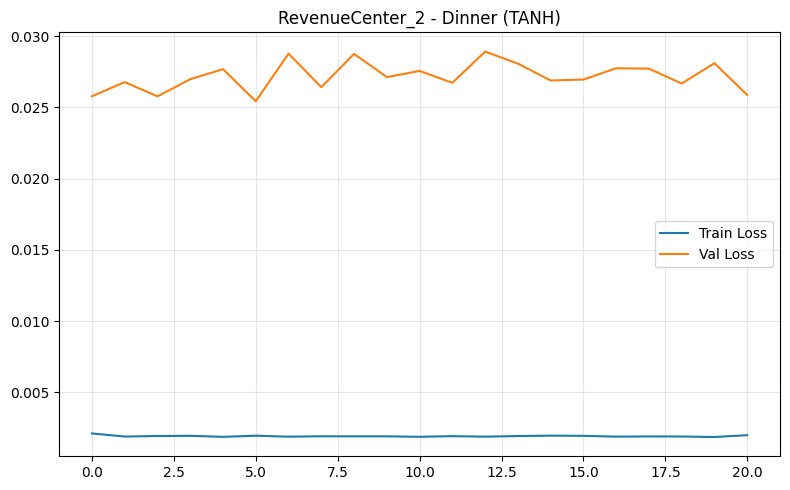

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


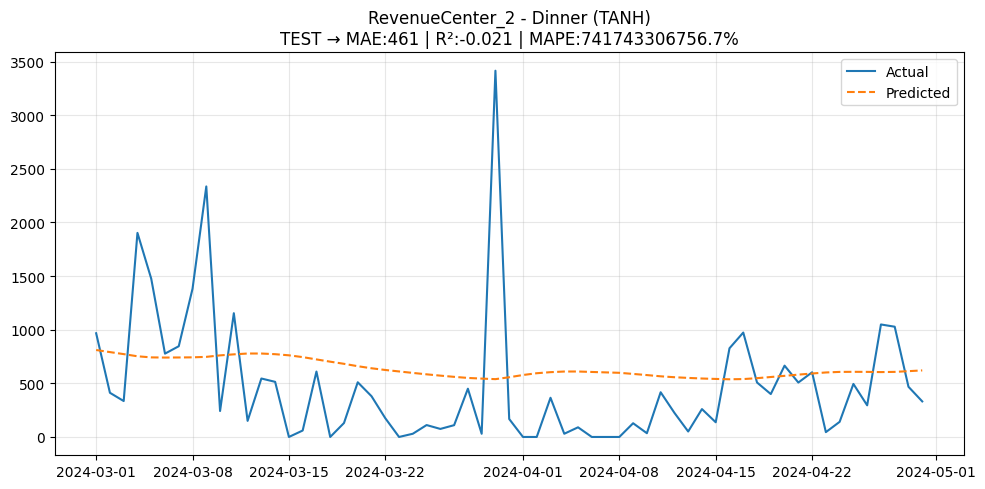

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_1
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0081 - val_loss: 0.0447
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0047 - val_loss: 0.0275
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0065 - val_loss: 0.0281
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0070 - val_loss: 0.0295
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0048 - val_loss: 0.0276
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0042 - val_loss: 0.0285
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0066 - val_loss: 0.0279
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0049 - val_loss: 0.0278
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0051 - val_loss: 0.0287
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0042 - val_loss: 0.0281
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0050 - val_loss: 0.0280
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

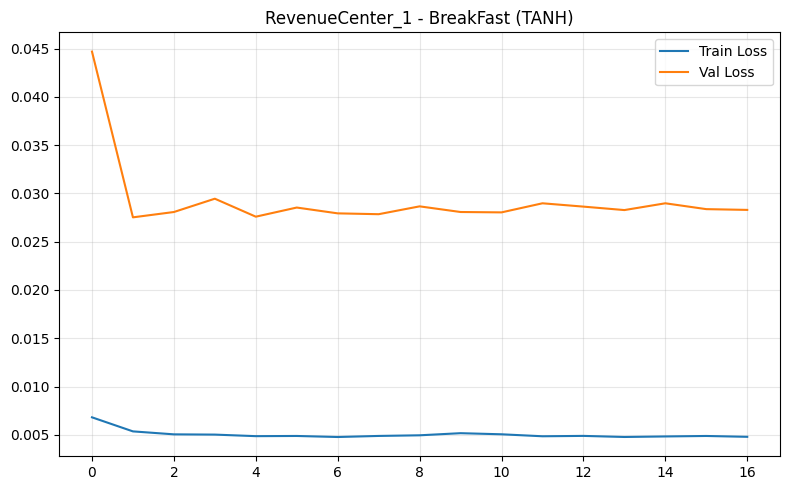

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


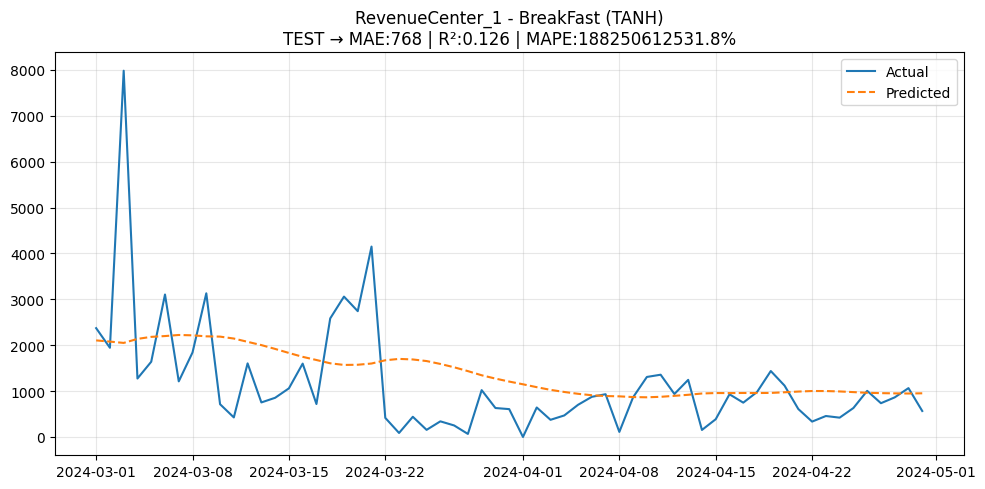

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0201 - val_loss: 0.0720
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0160 - val_loss: 0.0826
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0116 - val_loss: 0.0708
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0108 - val_loss: 0.0577
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0157 - val_loss: 0.0843
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0141 - val_loss: 0.0676
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0140 - val_loss: 0.0750
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0091 - val_loss: 0.0643
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0145 - val_loss: 0.0756
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0118 - val_loss: 0.0691
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0138 - val_loss: 0.0669
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0

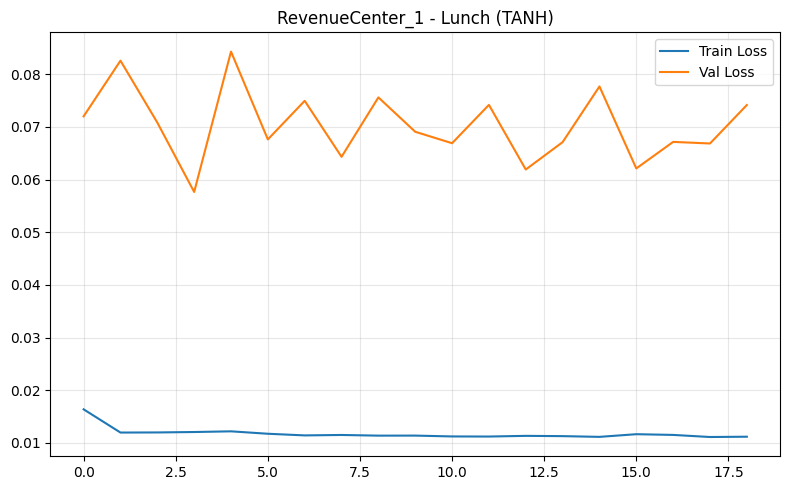

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


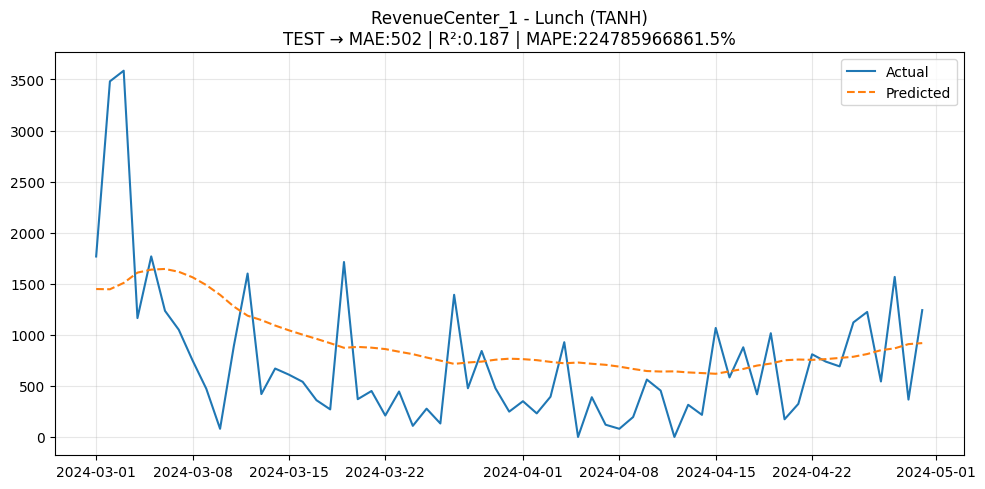

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0328 - val_loss: 0.0651
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0167 - val_loss: 0.0257
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0128 - val_loss: 0.0315
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0119 - val_loss: 0.0296
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0129 - val_loss: 0.0297
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0125 - val_loss: 0.0266
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0137 - val_loss: 0.0265
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0131 - val_loss: 0.0278
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0130 - val_loss: 0.0255
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0133 - val_loss: 0.0312
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0144 - val_loss: 0.0279
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0

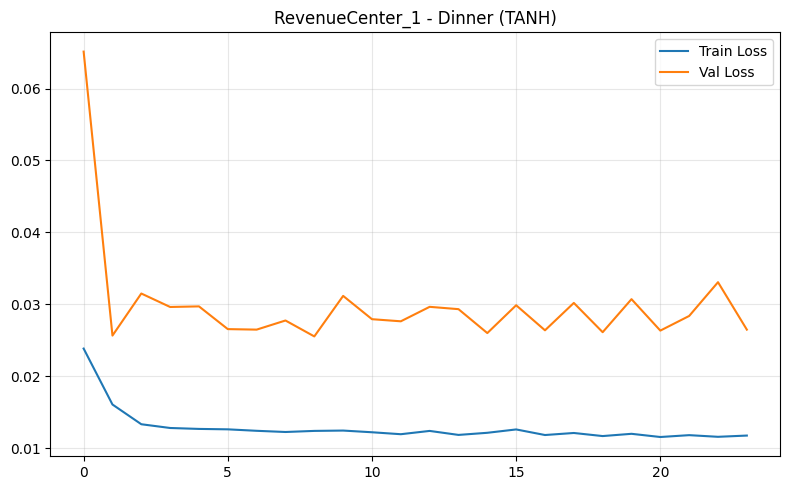

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


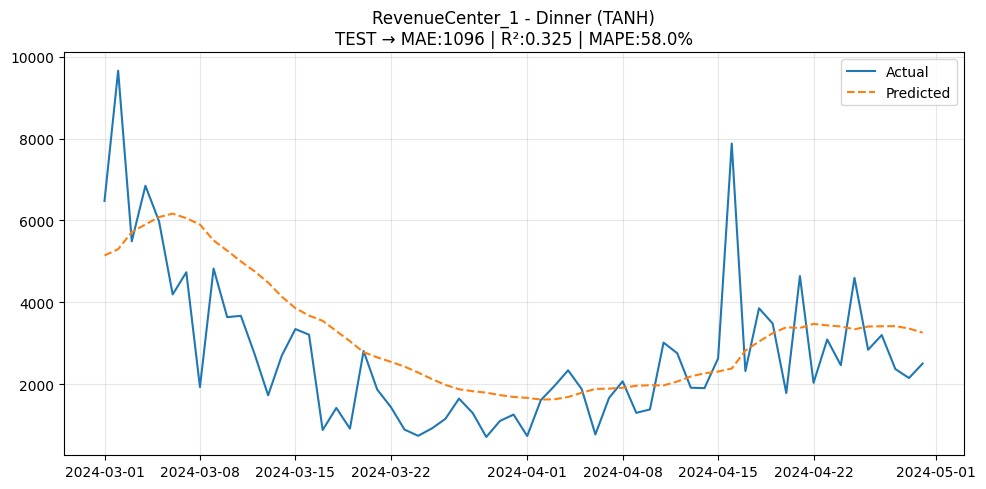

Saved: /content/RevenueCenter_1

Processing: RevenueCenter_6
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0247 - val_loss: 0.0493
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0169 - val_loss: 0.0508
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0234 - val_loss: 0.0510
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0242 - val_loss: 0.0492
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0249 - val_loss: 0.0496
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0230 - val_loss: 0.0499
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0253 - val_loss: 0.0503
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0226 - val_loss: 0.0497
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0215 - val_loss: 0.0501
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0284 - val_loss: 0.0508
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0164 - val_loss: 0.0502
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

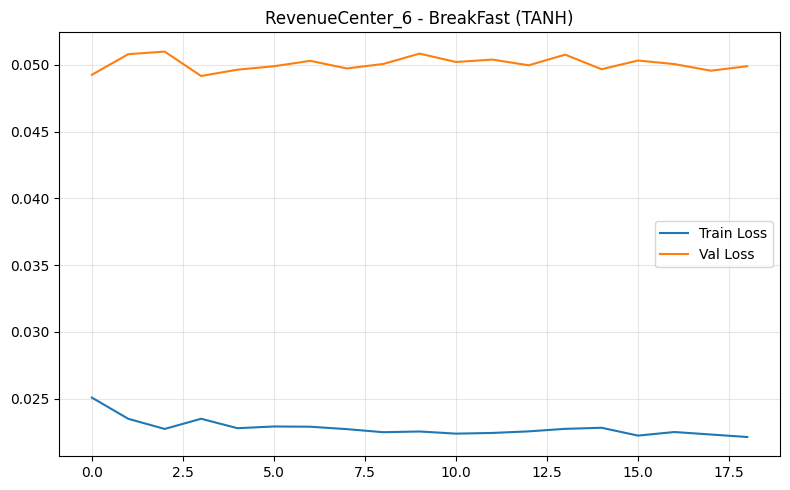

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


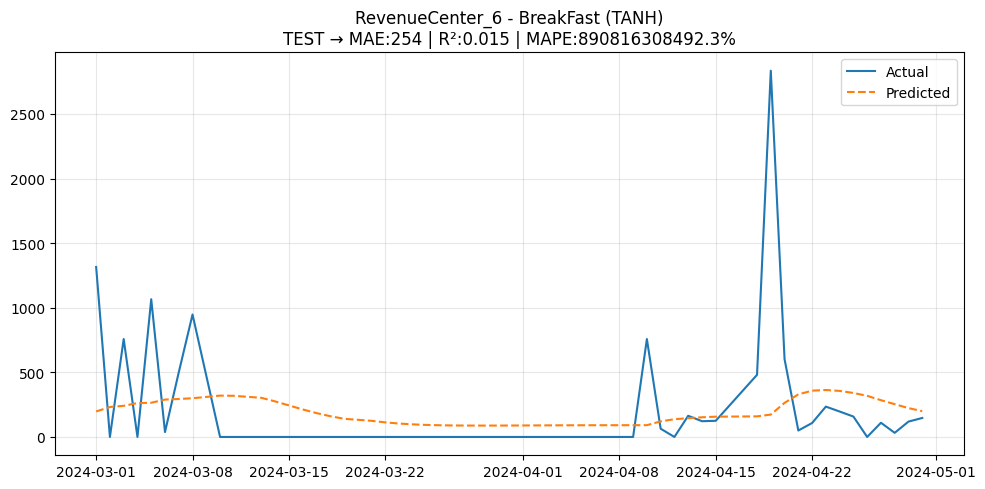

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0133 - val_loss: 0.0228
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0106 - val_loss: 0.0181
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0136 - val_loss: 0.0193
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0097 - val_loss: 0.0185
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0108 - val_loss: 0.0190
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0104 - val_loss: 0.0190
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0126 - val_loss: 0.0214
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0109 - val_loss: 0.0188
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0089 - val_loss: 0.0192
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0074 - val_loss: 0.0189
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0103 - val_loss: 0.0206
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

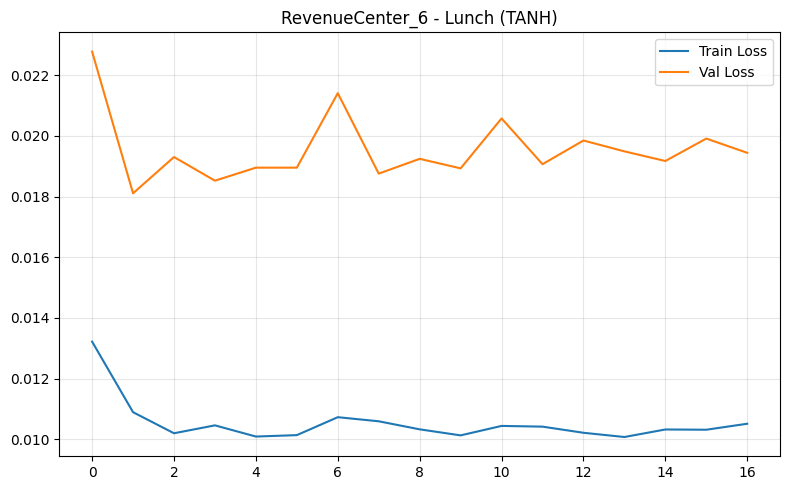

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


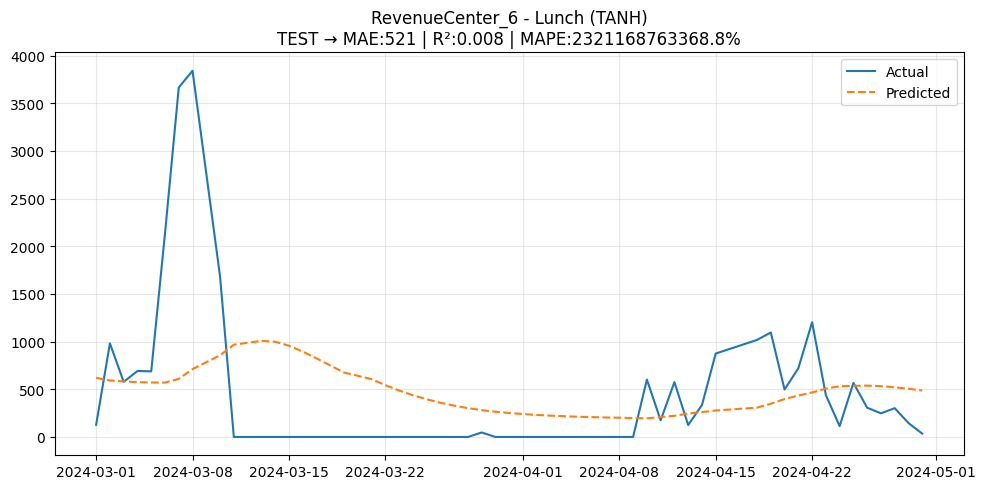

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0019 - val_loss: 0.0245
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0031 - val_loss: 0.0248
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0032 - val_loss: 0.0251
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0046 - val_loss: 0.0247
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0044 - val_loss: 0.0250
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0037 - val_loss: 0.0248
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0033 - val_loss: 0.0249
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0022 - val_loss: 0.0249
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0023 - val_loss: 0.0248
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0057 - val_loss: 0.0251
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0018 - val_loss: 0.0247
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

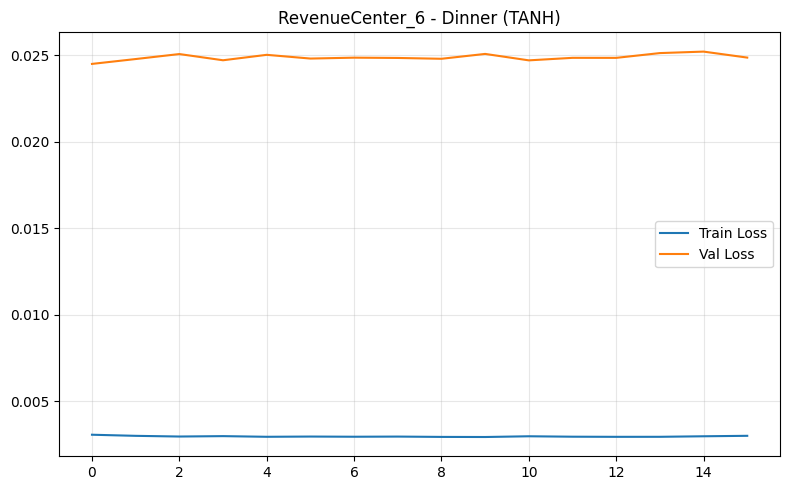

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


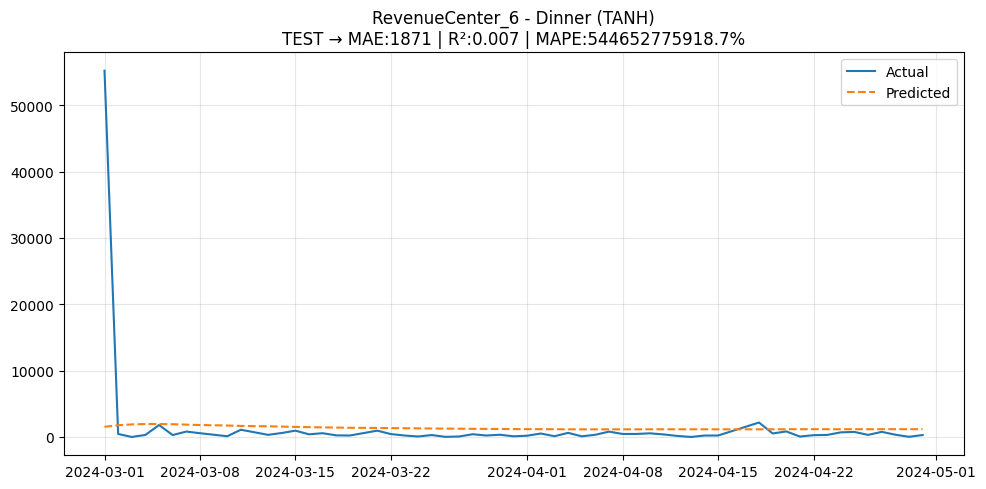

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_4
Skipping RevenueCenter_4 - BreakFast (constant values)
Skipping RevenueCenter_4 - Lunch (constant values)
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 7.7446e-04 - val_loss: 2.1303e-04
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0082 - val_loss: 3.8465e-05
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0027 - val_loss: 4.5072e-06
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0042 - val_loss: 6.3827e-06
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0010 - val_loss: 5.4090e-05
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.8525e-04 - val_loss: 1.2839e-06
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0022 - val_loss: 3.4215e-05
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0080 - val_loss: 9.6560e-06
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0027 - val_loss: 5.9653e-05
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014 - val_loss: 3.2709e-06
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0014 - val_loss: 2.8784e-05
Epoch 12/150

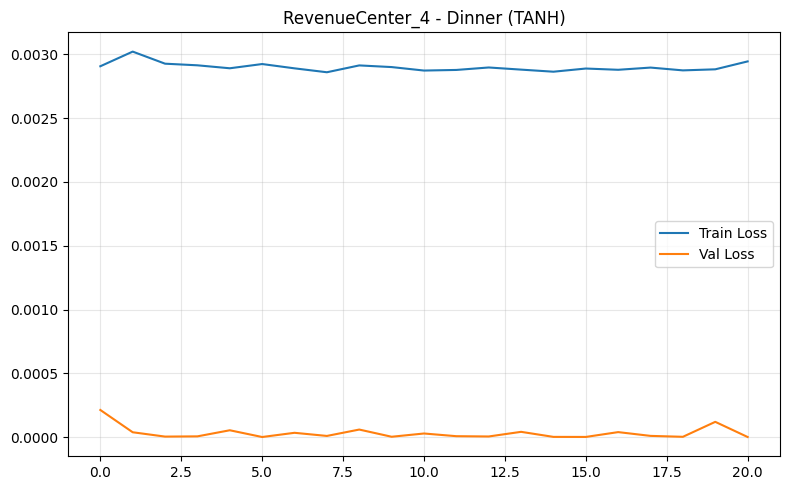

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


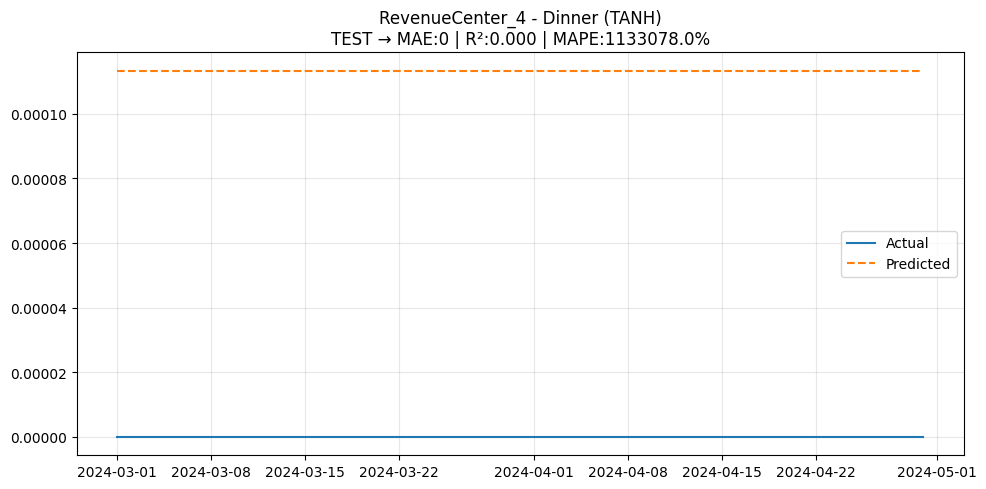

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_8
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0075 - val_loss: 0.0023
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0127 - val_loss: 0.0025
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0093 - val_loss: 0.0024
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0133 - val_loss: 0.0024
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0112 - val_loss: 0.0023
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0105 - val_loss: 0.0025
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0144 - val_loss: 0.0025
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0096 - val_loss: 0.0023
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0091 - val_loss: 0.0025
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0105 - val_loss: 0.0025
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0141 - val_loss: 0.0024
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

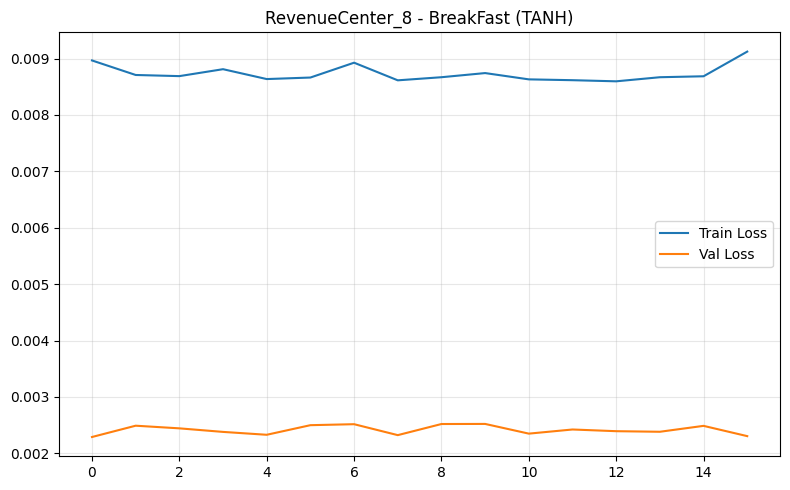

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


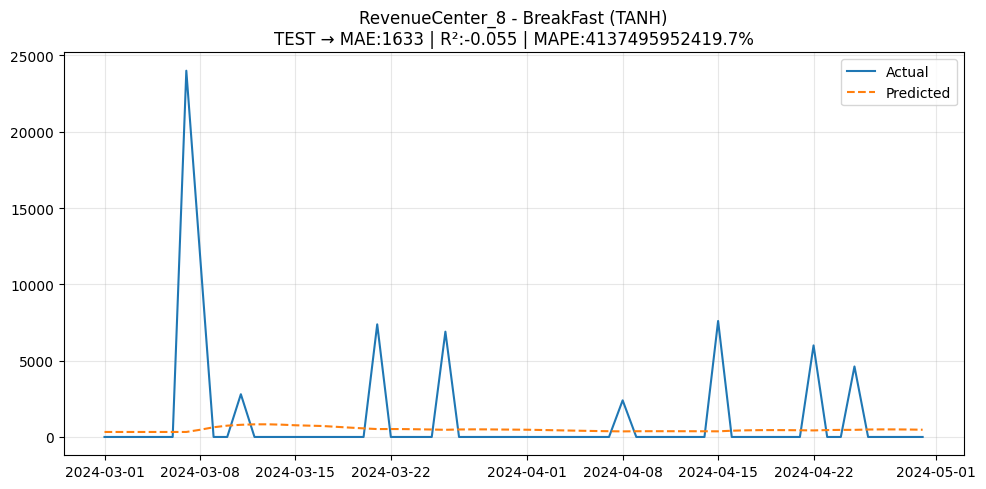

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0222 - val_loss: 0.1061
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0145 - val_loss: 0.1039
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0146 - val_loss: 0.1036
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0120 - val_loss: 0.1054
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0152 - val_loss: 0.1026
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0162 - val_loss: 0.1048
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0152 - val_loss: 0.1000
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0186 - val_loss: 0.1026
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0162 - val_loss: 0.1007
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0131 - val_loss: 0.0996
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0148 - val_loss: 0.1024
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0

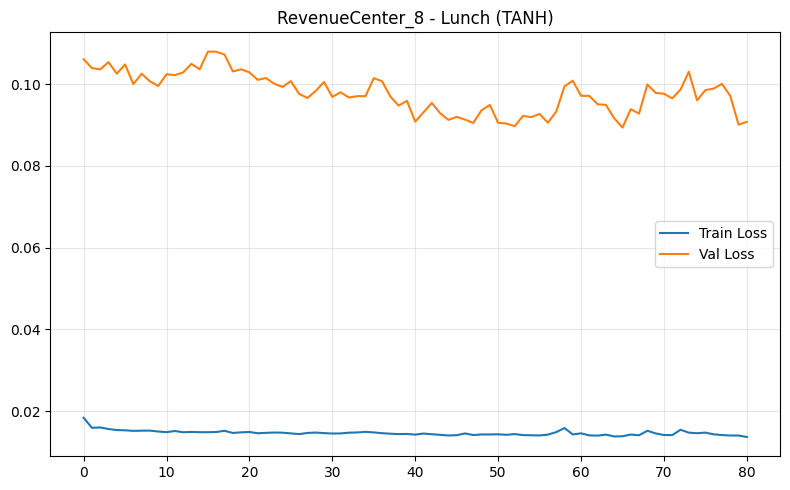

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


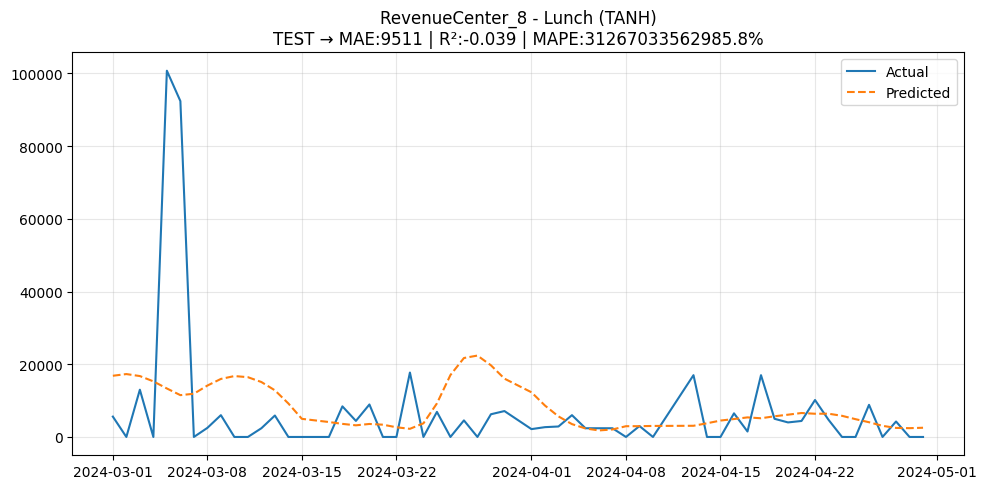

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0194 - val_loss: 0.0631
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0177 - val_loss: 0.0535
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0161 - val_loss: 0.0600
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0140 - val_loss: 0.0542
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0143 - val_loss: 0.0564
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0143 - val_loss: 0.0572
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0145 - val_loss: 0.0557
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0128 - val_loss: 0.0545
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0124 - val_loss: 0.0565
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0123 - val_loss: 0.0532
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0135 - val_loss: 0.0567
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0

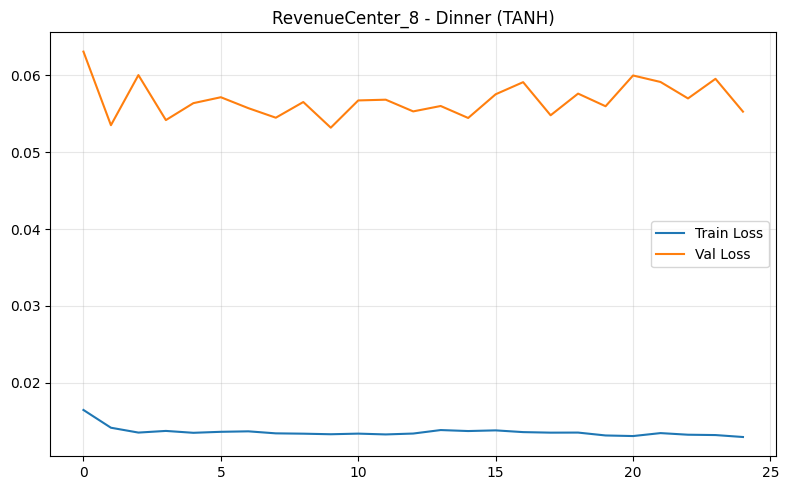

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


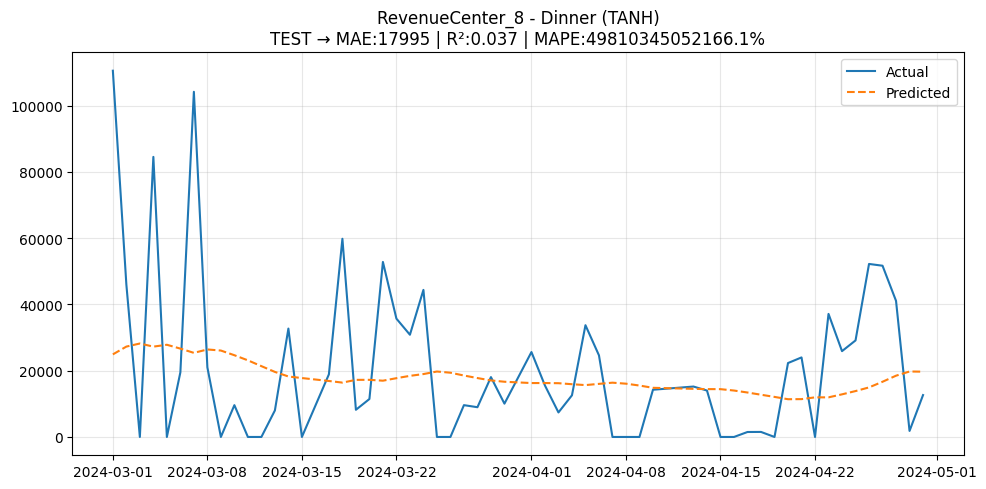

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_3
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0356 - val_loss: 0.0409
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0249 - val_loss: 0.0368
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0190 - val_loss: 0.0366
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0235 - val_loss: 0.0364
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0229 - val_loss: 0.0404
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0225 - val_loss: 0.0363
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0240 - val_loss: 0.0393
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0230 - val_loss: 0.0360
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0234 - val_loss: 0.0445
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0233 - val_loss: 0.0370
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0243 - val_loss: 0.0366
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0

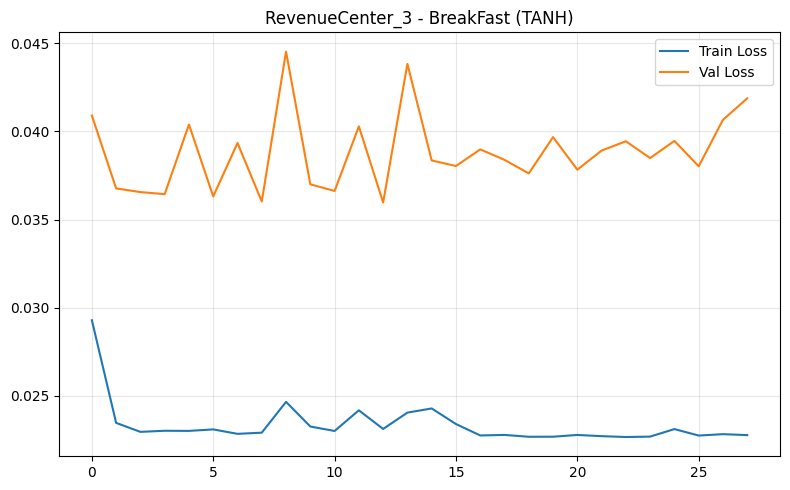

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


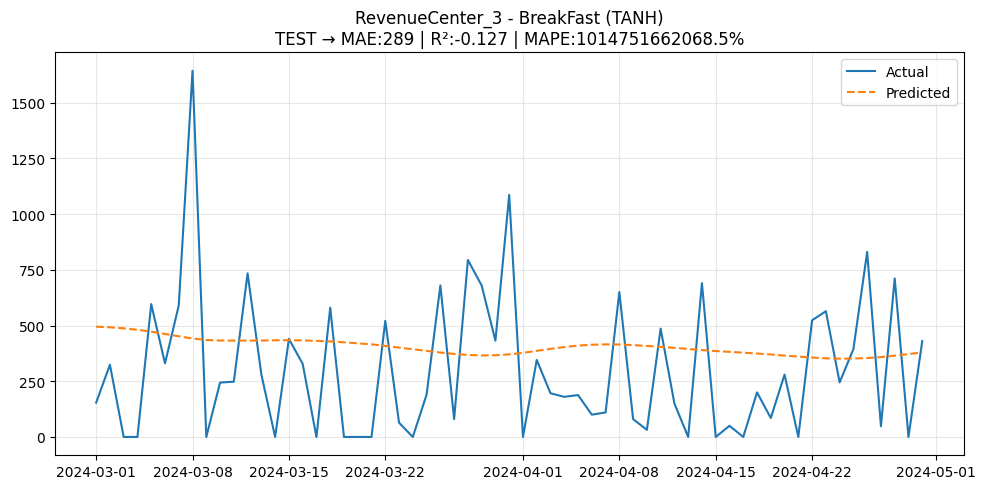

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0218 - val_loss: 0.0626
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0117 - val_loss: 0.0546
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0104 - val_loss: 0.0517
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0099 - val_loss: 0.0548
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0094 - val_loss: 0.0549
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0085 - val_loss: 0.0483
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0101 - val_loss: 0.0614
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0108 - val_loss: 0.0542
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0125 - val_loss: 0.0605
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0121 - val_loss: 0.0572
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0097 - val_loss: 0.0571
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

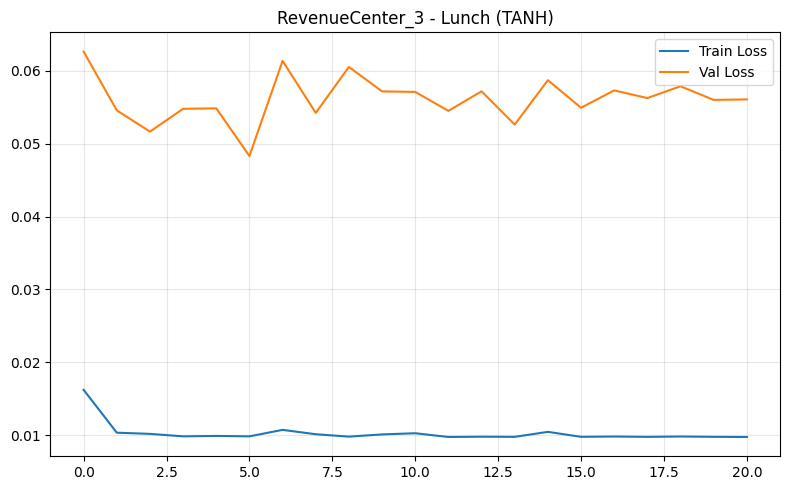

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


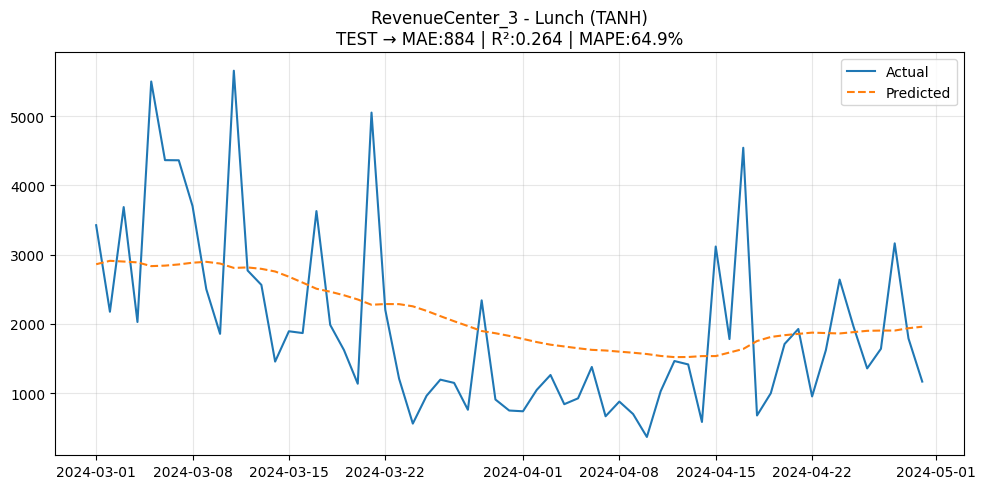

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0362 - val_loss: 0.1144
Epoch 2/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0137 - val_loss: 0.0495
Epoch 3/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0120 - val_loss: 0.0776
Epoch 4/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0101 - val_loss: 0.0590
Epoch 5/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0116 - val_loss: 0.0475
Epoch 6/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0110 - val_loss: 0.0636
Epoch 7/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0110 - val_loss: 0.0454
Epoch 8/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0097 - val_loss: 0.0449
Epoch 9/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0096 - val_loss: 0.0282
Epoch 10/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0111 - val_loss: 0.0440
Epoch 11/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0099 - val_loss: 0.0282
Epoch 12/150
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0

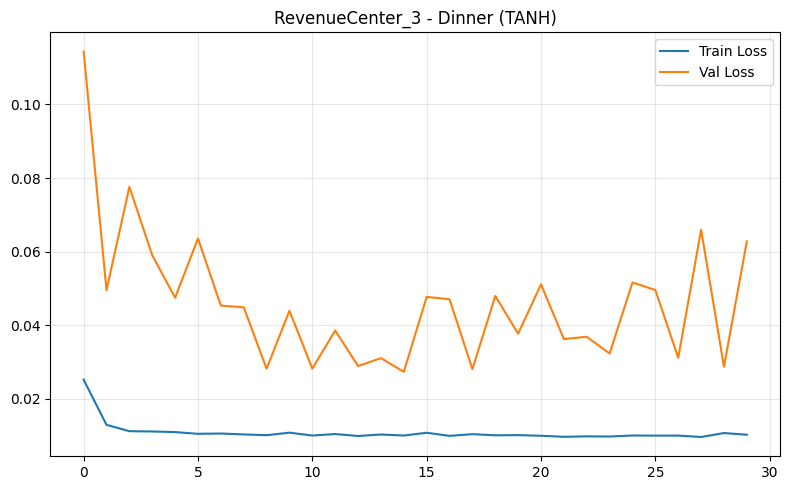

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


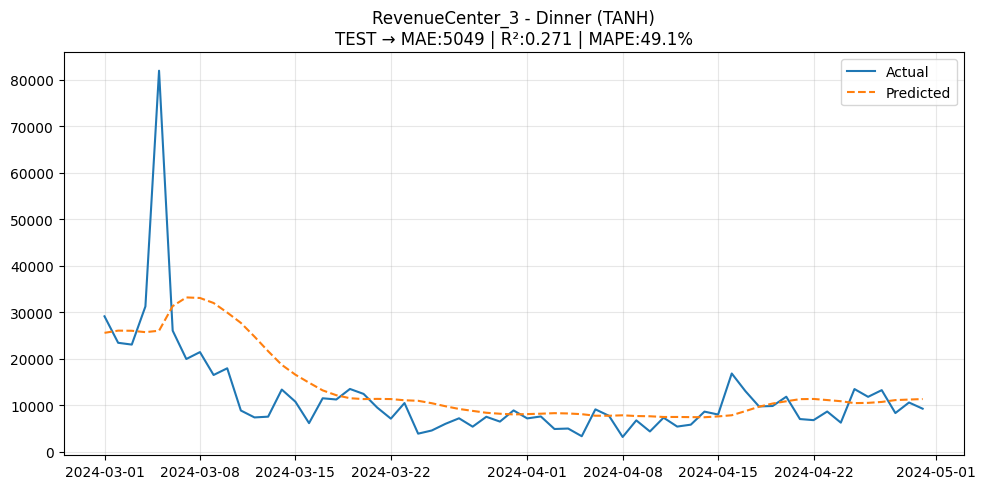

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_9
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0094 - val_loss: 0.0823
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0105 - val_loss: 0.0748
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0083 - val_loss: 0.0717
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0077 - val_loss: 0.0661
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0099 - val_loss: 0.0677
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0083 - val_loss: 0.0668
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0084 - val_loss: 0.0664
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0084 - val_loss: 0.0688
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0081 - val_loss: 0.0686
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0088 - val_loss: 0.0777
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0106 - val_loss: 0.0776
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0

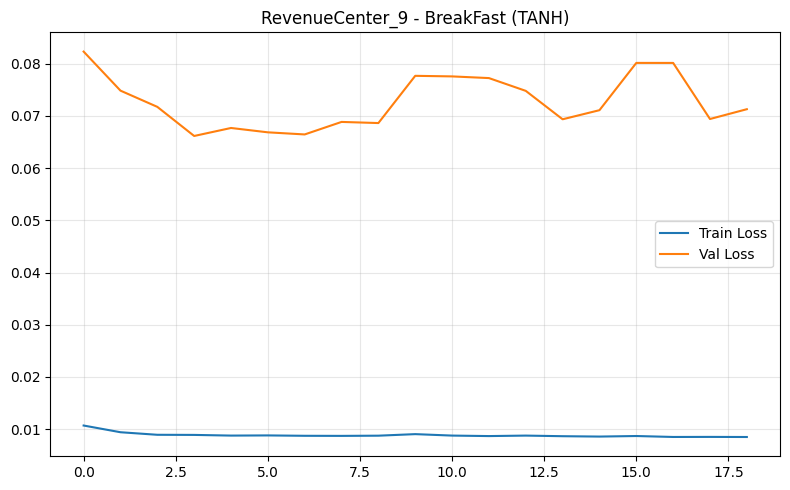

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


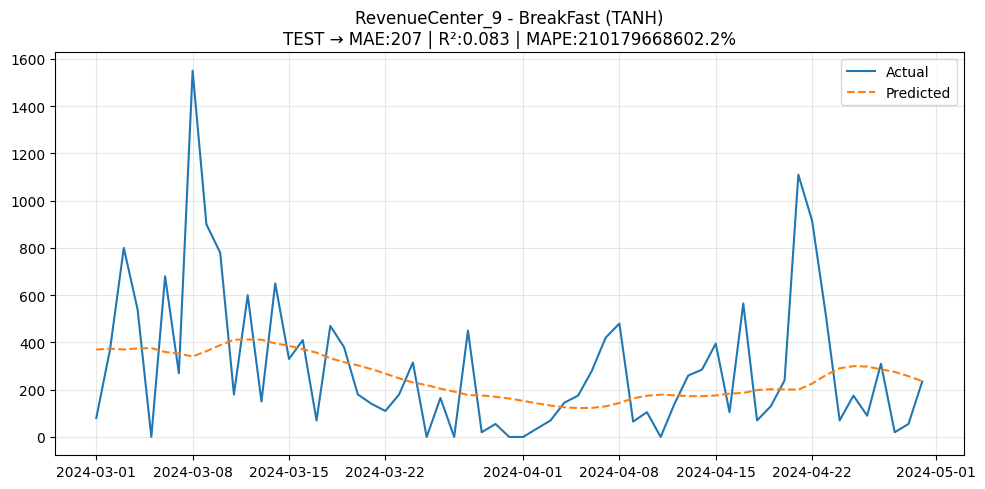

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0511 - val_loss: 0.0499
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0355 - val_loss: 0.0486
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0347 - val_loss: 0.0473
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0314 - val_loss: 0.0474
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0379 - val_loss: 0.0494
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0386 - val_loss: 0.0483
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0294 - val_loss: 0.0470
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0338 - val_loss: 0.0478
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0295 - val_loss: 0.0478
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0324 - val_loss: 0.0478
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0307 - val_loss: 0.0482
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0

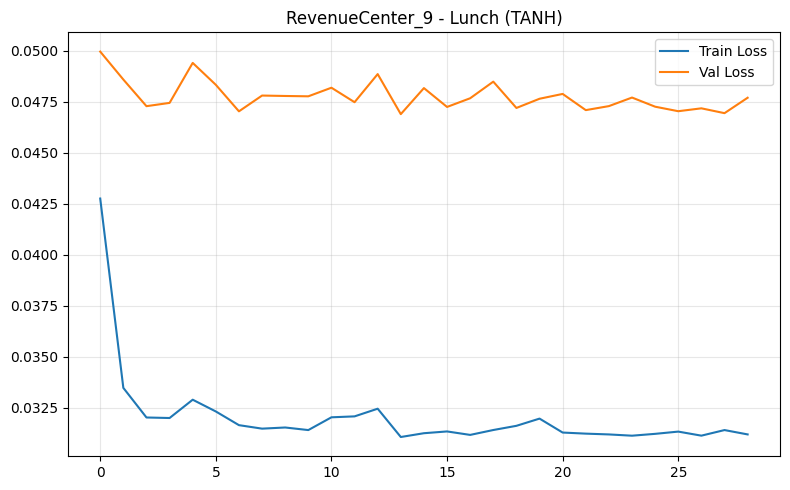

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


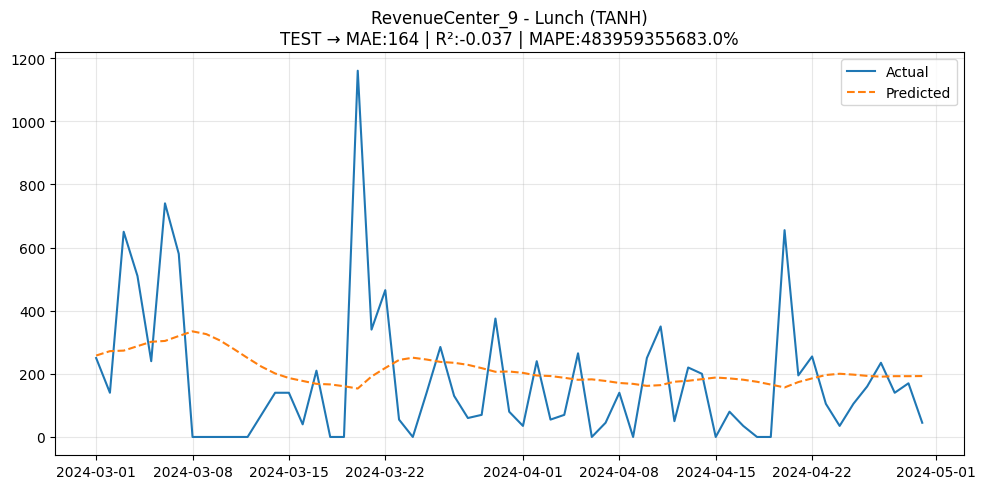

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0260 - val_loss: 0.0133
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0138 - val_loss: 0.0157
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0225 - val_loss: 0.0135
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0203 - val_loss: 0.0138
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0215 - val_loss: 0.0141
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0218 - val_loss: 0.0138
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0199 - val_loss: 0.0142
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0226 - val_loss: 0.0141
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0249 - val_loss: 0.0139
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0220 - val_loss: 0.0141
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0258 - val_loss: 0.0141
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0

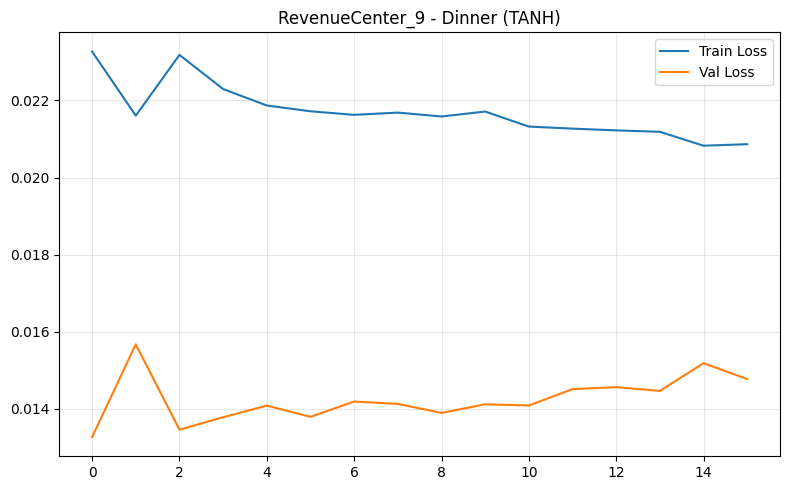

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


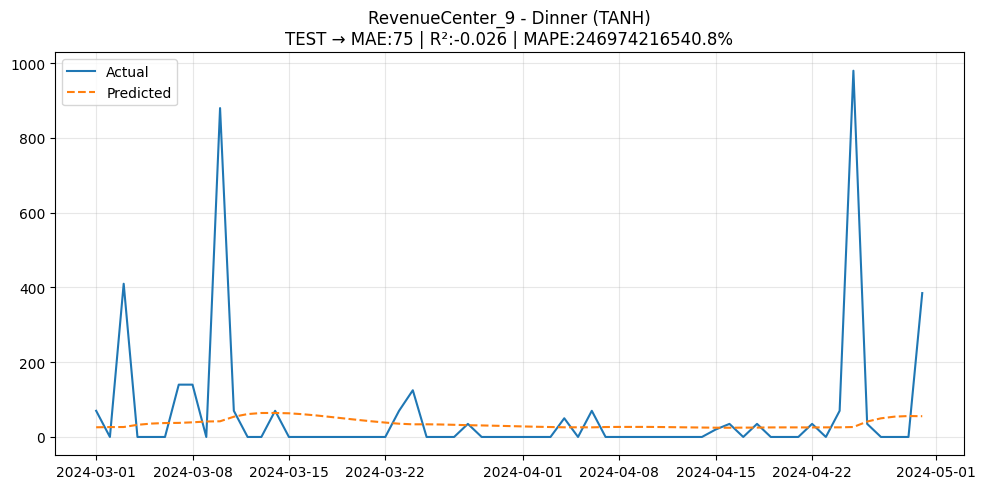

Saved: /content/RevenueCenter_9

ALL CENTERS COMPLETED — TANH MODEL


In [17]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            print(f"Skipping {center_name} - {meal} (constant values)")
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — TANH
        # =========================
        model = Sequential([

            LSTM(
                128,
                activation="tanh",
                return_sequences=True,
                input_shape=(WINDOW, 1)
            ),

            LSTM(
                64,
                activation="tanh",
                return_sequences=False
            ),

            Dense(32, activation="relu"),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=150,
            batch_size=32,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (TANH)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_tanh.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (TANH)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — TANH MODEL")

In [ ]:
y_min = y_train.min()
y_max = y_train.max()

print("Target range:", y_min, "to", y_max)
print("Range width:", y_max - y_min)

Target range: 0.0 to 37870.0
Range width: 37870.0
